In [40]:
# Imports
import numpy as np
import sys
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt
import torch
import copy
import torch.nn.functional as F
from collections import Counter

# Custom Imports
root_dir = Path('.').resolve().parent
src_path = str(root_dir / "src")

if src_path not in sys.path :
    sys.path.append(src_path)

from model_explainability_Carpus import (test_node, explainer_captum, explanation_captum)
from model_train import (model, data)
from feature_engineering import (id_to_relation, edge_type)

from model_explainability import (explainer)

# Single Node EVALUATE & VISUALIZE


Top 20 Captum Relations Breakdown:
Counter({'author': 4, 'isAbout': 4, 'publication': 4, 'type': 2, 'isWorkedOnBy': 2, 'subClassOf': 1, 'hasProject': 1, 'publishes': 1, 'dealtWithIn': 1})


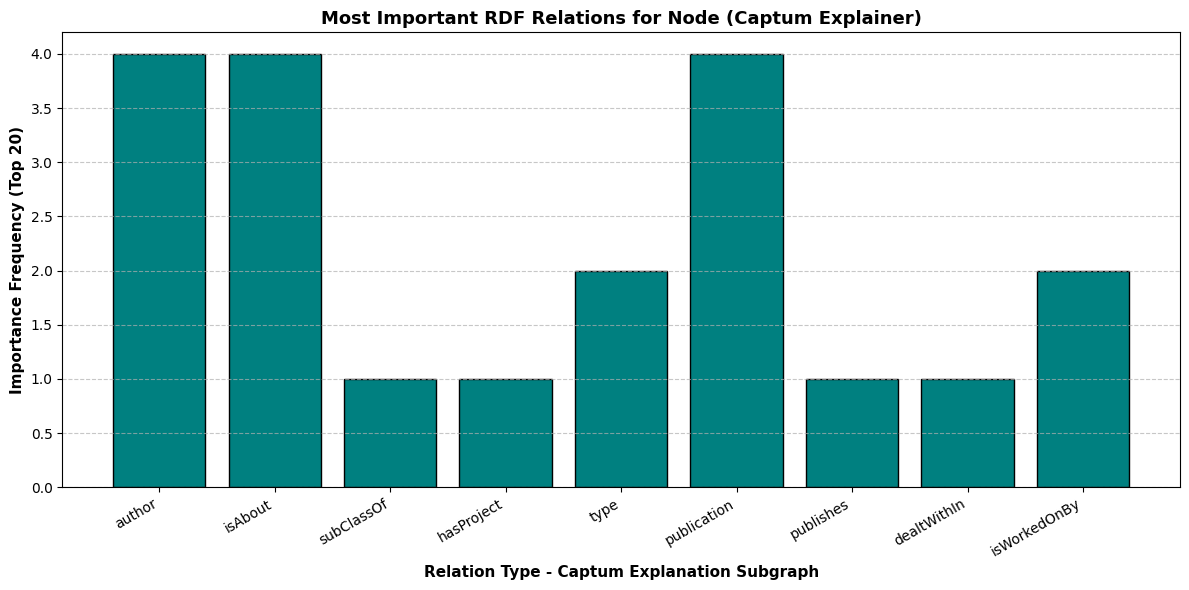

In [13]:
# 1. Identify the top 20 most important edges according to Captum
# Gradient values can be negative (pushing away from class) or positive (pushing toward class), 
# so we take the absolute value to find the strongest overall impacts.
absolute_edge_mask = torch.abs(explanation_captum.edge_mask)
topk_values, topk_edge_indices = absolute_edge_mask.topk(20)

# 2. Extract and clean the relation names for those top edges
important_relations = []

for idx in topk_edge_indices:
    idx = idx.item()
    
    # Map the edge index back to its relation ID from feature engineering
    rel_id = edge_type[idx].item()
    
    # Fetch the original ontology URI string
    relation_uri = id_to_relation[rel_id]
    
    # Clean the URI (e.g., "http://...#affiliation" -> "affiliation")
    clean_relation = relation_uri.split("#")[-1]
    important_relations.append(clean_relation)

# 3. Calculate frequencies of the top driving relations
relation_counts = Counter(important_relations)
print("\nTop 20 Captum Relations Breakdown:")
print(relation_counts)

# 4. Generate the Comparison Bar Chart
relations = list(relation_counts.keys())
counts = list(relation_counts.values())

plt.figure(figsize=(12, 6))
plt.bar(relations, counts, color='teal', edgecolor='black')
plt.xlabel("Relation Type - Captum Explanation Subgraph", fontsize=11, fontweight='bold')
plt.ylabel("Importance Frequency (Top 20)", fontsize=11, fontweight='bold')
plt.title(f"Most Important RDF Relations for Node (Captum Explainer)", fontsize=13, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Multiple Nodes Evaluation & Visulisation

### Author-to-paper connection is the most vital piece of information the GCN uses to determine a node's affiliation.

Generating Captum explanations for 10 nodes...
Successfully processed Node ID: 307
Successfully processed Node ID: 682
Successfully processed Node ID: 2290
Successfully processed Node ID: 546
Successfully processed Node ID: 1026
Successfully processed Node ID: 246
Successfully processed Node ID: 1889
Successfully processed Node ID: 2808
Successfully processed Node ID: 1742
Successfully processed Node ID: 2305


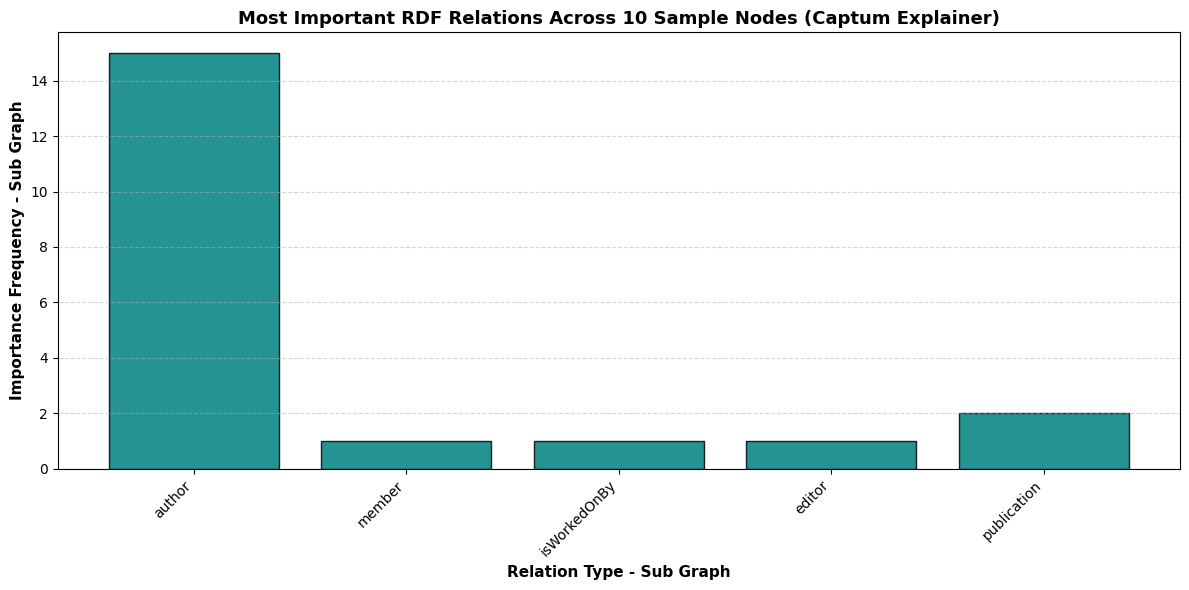

In [19]:
# CAPTUM MULTIPLE NODE EXPLANATION & VISUALIZATION
# =====================================================================
# 1. Define the subset of test nodes you want to explain (e.g., first 10 nodes)
num_nodes_to_explain = min(10, len(test_nodes))
selected_test_nodes = test_nodes[:num_nodes_to_explain]

print(f"Generating Captum explanations for {num_nodes_to_explain} nodes...")

# 2. Set up total edges using your imported edge_type tensor length
num_edges = edge_type.shape[0]
aggregated_edge_mask = torch.zeros(num_edges)
successful_nodes = 0

# 3. Process each node subgraph sequentially
for node_idx in selected_test_nodes:
    node_id = int(node_idx)
    try:
        # Generate the explanation from your running Captum explainer module
        exp = explainer_captum(
            x = data.x,
            edge_index = data.edge_index,
            index = node_id
        )
        
        # Accumulate absolute attribution values (both negative and positive 
        # gradients represent strong structural influence on predictions)
        aggregated_edge_mask += torch.abs(exp.edge_mask)
        successful_nodes += 1
        print(f"Successfully processed Node ID: {node_id}")
        
    except Exception as e:
        print(f"Skipping Node ID {node_id} due to framework evaluation error: {e}")

# 4. Extract, Clean, and Count the Top 20 Global Relations
if successful_nodes > 0:
    # Compute the average attribution magnitude across successfully checked subgraphs
    aggregated_edge_mask /= successful_nodes
    
    # Extract indices of the top 20 globally most vital graph edges
    topk_values, topk_edge_indices = aggregated_edge_mask.topk(20)
    
    important_relations = []
    for idx in topk_edge_indices:
        idx = idx.item()
        
        # Map back to the numeric relation ID from feature engineering
        rel_id = edge_type[idx].item()
        
        # Fetch the original ontology URI string
        relation_uri = id_to_relation[rel_id]
        
        # Strip the URI prefix cleanly (e.g., "http://...#publication" -> "publication")
        clean_relation = relation_uri.split("#")[-1]
        important_relations.append(clean_relation)
        
    global_relation_counts = Counter(important_relations)
    
    # 5. Generate the Matching Bar Graph
    relations = list(global_relation_counts.keys())
    counts = list(global_relation_counts.values())
    
    plt.figure(figsize=(12, 6))
    # Using 'teal' to easily distinguish your Captum chart from the standard GNN chart
    plt.bar(relations, counts, color='teal', edgecolor='black', alpha=0.85)
    plt.xlabel("Relation Type - Sub Graph", fontsize=11, fontweight='bold')
    plt.ylabel("Importance Frequency - Sub Graph", fontsize=11, fontweight='bold')
    plt.title(f"Most Important RDF Relations Across {successful_nodes} Sample Nodes (Captum Explainer)", fontsize=13, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

else:
    print("\nError: No node explanations could be evaluated. Double check your data parameters.")

In [21]:
from feature_engineering import g
from rdflib import Literal

# Count how many times each predicate appears in your filtered training triples
from collections import Counter
predicates = [str(p).split("#")[-1] for s, p, o in g if not isinstance(o, Literal)]
print(Counter(predicates))

Counter({'publication': 4163, 'type': 4124, 'author': 3986, 'isAbout': 2477, 'publishes': 1217, 'hasProject': 952, 'projectInfo': 952, 'isWorkedOnBy': 571, 'dealtWithIn': 357, 'member': 339, 'worksAtProject': 200, 'subClassOf': 199, 'editor': 190, 'affiliation': 178, 'onProperty': 152, 'allValuesFrom': 152, 'carriedOutBy': 79, 'carriesOut': 79, 'finances': 68, 'financedBy': 65, 'inverseOf': 10, 'head': 5, 'employs': 5, 'range': 1})


# Faithfullness Check

#### 1. Remove Important Edges
#### 2. Check Drop in Confidence 

In [ ]:
# Put model in evaluation mode
model.eval()

# Setup tracking lists for final metrics
confidence_drops = []
prediction_changed_count = 0
total_evaluated_nodes = 0

# Select the subset of test nodes
num_nodes_to_explain = min(10, len(test_nodes))
selected_test_nodes = test_nodes[:num_nodes_to_explain]

for node_idx in selected_test_nodes:
    node_id = int(node_idx)
    
    try:
        # TASK 1: Get Original Prediction & Confidence (Passing edge_type)

        with torch.no_grad():
            # Pass BOTH edge_index and edge_type to your R-GCN
            orig_logits = model(data.x, data.edge_index, edge_type)
            orig_probs = F.softmax(orig_logits[node_id], dim=-1)
            orig_pred_class = torch.argmax(orig_probs).item()
            orig_confidence = orig_probs[orig_pred_class].item()
            
        # TASK 2: Identify and Remove Important Edges & Edge Types

        exp = explainer_captum(
            x = data.x,
            edge_index = data.edge_index,
            index = node_id
        )
        
        node_edge_mask = torch.abs(exp.edge_mask)
        _, top_local_edge_indices = node_edge_mask.topk(min(20, len(node_edge_mask)))
        
        # Create a boolean mask to filter out the top 20 edges
        keep_edge_mask = torch.ones(data.edge_index.shape[1], dtype=torch.bool)
        keep_edge_mask[top_local_edge_indices] = False
        
        perturbed_edge_index = data.edge_index[:, keep_edge_mask]
        perturbed_edge_type = edge_type[keep_edge_mask]  # <-- Crucial R-GCN step!
        
        # TASK 3: Run Model Again on the Perturbed Graph Structure

        with torch.no_grad():
            # Pass the newly modified edge index and corresponding types
            perturbed_logits = model(data.x, perturbed_edge_index, perturbed_edge_type)
            perturbed_probs = F.softmax(perturbed_logits[node_id], dim=-1)
            perturbed_confidence = perturbed_probs[orig_pred_class].item()
            new_pred_class = torch.argmax(perturbed_probs).item()
            
        # TASK 4: Compare Prediction Confidence & Track Metrics

        conf_drop = orig_confidence - perturbed_confidence
        confidence_drops.append(conf_drop)
        
        status = "STABLE"
        if orig_pred_class != new_pred_class:
            prediction_changed_count += 1
            status = "CHANGED"
            
        total_evaluated_nodes += 1
        
    except Exception as e:
        print(f"Skipping Node ID {node_id} due to runtime evaluation error: {e}")

=== Starting Faithfulness Check (Edge Deletion Analysis) ===



In [36]:
# FINAL REPORT STATISTICS REPORT

if total_evaluated_nodes > 0:
    avg_conf_drop = sum(confidence_drops) / total_evaluated_nodes
    flip_rate = (prediction_changed_count / total_evaluated_nodes) * 100
    
    print("\n" + "="*50)
    print("FINAL FAITHFULNESS SUMMARY METRICS")
    print("="*50)
    print(f"Total Nodes Evaluated : {total_evaluated_nodes}")
    print(fr"Average Confidence Drop (Delta Conf) : {avg_conf_drop:.4f} ({avg_conf_drop*100:.1f}%)")
    print(f"Prediction Label Flip Rate        : {flip_rate:.1f}%")
    print("="*50)
else:
    print("Evaluation failed: No nodes were successfully perturbed.")


FINAL FAITHFULNESS SUMMARY METRICS
Total Nodes Evaluated : 10
Average Confidence Drop (Delta Conf) : 0.0014 (0.1%)
Prediction Label Flip Rate        : 10.0%


# Overall Performance

In [52]:
# Ensure the multi-relational R-GCN model is in evaluation mode
model.eval()

# Select a subset of test nodes (e.g., the first 10)
nodes_to_evaluate = test_nodes[:10]
num_nodes = len(nodes_to_evaluate)

# Dictionary to store the baseline information for each node
baselines = {}

print("--- Computing Base Predictions ---")
with torch.no_grad():
    # Run a single forward pass on the full graph
    orig_output = model(data.x, data.edge_index, edge_type)
    
    for node in nodes_to_evaluate:
        node_id = int(node.item()) if isinstance(node, torch.Tensor) else int(node)
        
        # Calculate soft probabilities
        orig_probs = F.softmax(orig_output[node_id], dim=0)
        pred_class = torch.argmax(orig_probs).item()
        base_confidence = orig_probs[pred_class].item()
        
        # Save baseline configuration
        baselines[node_id] = {
            'pred_class': pred_class,
            'base_confidence': base_confidence
        }
        print(f"Node {node_id:4d} | Predicted Class: {pred_class} | Initial Confidence: {base_confidence:.4f}")

print(f"\nCell 1 Complete: Cached base metrics for {num_nodes} nodes.")

--- Computing Base Predictions ---
Node  307 | Predicted Class: 3 | Initial Confidence: 0.2048
Node  682 | Predicted Class: 3 | Initial Confidence: 0.2103
Node 2290 | Predicted Class: 1 | Initial Confidence: 0.2157
Node  546 | Predicted Class: 0 | Initial Confidence: 0.2025
Node 1026 | Predicted Class: 1 | Initial Confidence: 0.2096
Node  246 | Predicted Class: 3 | Initial Confidence: 0.2087
Node 1889 | Predicted Class: 1 | Initial Confidence: 0.2112
Node 2808 | Predicted Class: 3 | Initial Confidence: 0.2084
Node 1742 | Predicted Class: 1 | Initial Confidence: 0.2028
Node 2305 | Predicted Class: 3 | Initial Confidence: 0.2097

Cell 1 Complete: Cached base metrics for 10 nodes.


In [53]:
# Cell 2: Extract Explanations using Captum
import time

# Dictionary to store the cloned edge masks decoupled from Captum's internal state
captum_edge_masks = {}
execution_times = []

print("--- Running Captum Mask Extraction ---")
for node in nodes_to_evaluate:
    node_id = int(node.item()) if isinstance(node, torch.Tensor) else int(node)
    
    t0 = time.time()
    # explainer_captum must be your instantiated Captum object from your notebook
    explanation = explainer_captum(x=data.x, edge_index=data.edge_index, index=node_id)
    elapsed_time = time.time() - t0
    
    execution_times.append(elapsed_time)
    
    # Take absolute values of the edge masks and clone them safely
    captum_edge_masks[node_id] = torch.abs(explanation.edge_mask).clone()
    print(f"Node {node_id:4d} | Captum Extraction Time: {elapsed_time:.4f}s")

print("\nCell 2 Complete: All Captum masks extracted successfully.")

--- Running Captum Mask Extraction ---
Node  307 | Captum Extraction Time: 5.8333s
Node  682 | Captum Extraction Time: 5.7915s
Node 2290 | Captum Extraction Time: 5.8761s
Node  546 | Captum Extraction Time: 5.8183s
Node 1026 | Captum Extraction Time: 6.0504s
Node  246 | Captum Extraction Time: 5.8069s
Node 1889 | Captum Extraction Time: 6.0571s
Node 2808 | Captum Extraction Time: 6.6032s
Node 1742 | Captum Extraction Time: 6.0459s
Node 2305 | Captum Extraction Time: 5.9212s

Cell 2 Complete: All Captum masks extracted successfully.


In [54]:
# Cell 3: Evaluate Performance via Edge Mask Perturbation
fidelity_drops = []
sparsities = []

print("--- Evaluating Subgraph Perturbation Metrics ---")
with torch.no_grad():
    total_edges = data.edge_index.shape[1]
    
    for node in nodes_to_evaluate:
        node_id = int(node.item()) if isinstance(node, torch.Tensor) else int(node)
        
        # Retrieve baseline variables
        pred_class = baselines[node_id]['pred_class']
        c_original = baselines[node_id]['base_confidence']
        
        # Extract edge mask and select top-K important edges (e.g., top 20)
        mask = captum_edge_masks[node_id]
        k = min(20, len(mask))
        top_edges = mask.topk(k).indices
        
        # Compute Sparsity: fraction of edges removed
        sparsity_score = 1.0 - (len(top_edges) / total_edges)
        sparsities.append(sparsity_score)
        
        # Create a boolean selection mask (True = keep edge, False = drop edge)
        keep_mask = torch.ones(total_edges, dtype=torch.bool)
        keep_mask[top_edges] = False
        
        # Run forward pass on the PERTURBED graph structure
        perturbed_output = model(
            data.x, 
            data.edge_index[:, keep_mask], 
            edge_type[keep_mask]
        )
        
        perturbed_probs = F.softmax(perturbed_output[node_id], dim=0)
        c_perturbed = perturbed_probs[pred_class].item()
        
        # Confidence Drop (Higher value = Captum successfully pinpointed core structural edges)
        drop = c_original - c_perturbed
        fidelity_drops.append(drop)
        print(f"Node {node_id:4d} | Confidence Drop: {drop:+.4f} (Remaining: {c_perturbed:.4f})")

# ---------------------------------------------------------------------
# FINAL PERFORMANCE AGGREGATION DISPLAY
# ---------------------------------------------------------------------
avg_drop = sum(fidelity_drops) / num_nodes
avg_time = sum(execution_times) / num_nodes
avg_sparsity = sum(sparsities) / num_nodes

print("\n" + "="*55)
print(f"{'CAPTUM STANDALONE PERFORMANCE METRICS':^55}")
print("="*55)
print(f"{'Avg Confidence Drop (Higher=Better)':<38} | {avg_drop:.4f}")
print(f"{'Avg Execution Time (Lower=Better)':<38} | {avg_time:.4f}s")
print(f"{'Subgraph Sparsity (Higher=Better)':<38} | {avg_sparsity:.2%}")
print("="*55)

--- Evaluating Subgraph Perturbation Metrics ---
Node  307 | Confidence Drop: +0.0000 (Remaining: 0.2048)
Node  682 | Confidence Drop: -0.0048 (Remaining: 0.2151)
Node 2290 | Confidence Drop: +0.0098 (Remaining: 0.2059)
Node  546 | Confidence Drop: +0.0000 (Remaining: 0.2025)
Node 1026 | Confidence Drop: +0.0014 (Remaining: 0.2082)
Node  246 | Confidence Drop: +0.0052 (Remaining: 0.2035)
Node 1889 | Confidence Drop: +0.0019 (Remaining: 0.2093)
Node 2808 | Confidence Drop: +0.0000 (Remaining: 0.2084)
Node 1742 | Confidence Drop: +0.0000 (Remaining: 0.2028)
Node 2305 | Confidence Drop: +0.0000 (Remaining: 0.2097)

         CAPTUM STANDALONE PERFORMANCE METRICS         
Avg Confidence Drop (Higher=Better)    | 0.0014
Avg Execution Time (Lower=Better)      | 5.9804s
Subgraph Sparsity (Higher=Better)      | 99.90%
